In [9]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),  # переводит в тензор формата (C, H, W) каналы высота и ширина и нормализует пиксели в [ 0  1 ] делит все значения на 255
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # нормализуем пиксели RGB  transforms.Normalize(mean, std) xнорм​=(x−mean​/std) [-1  1]
])
# Где mean = (0.5, 0.5, 0.5) и std = (0.5, 0.5, 0.5) — по одному значению на каждый канал RGB.

In [11]:
#Скачиваем бинарный архив и распаковываем его
train_dataset = torchvision.datasets.CIFAR10(root='./', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./', train=False, download=True, transform=transform)


'\n2️⃣ train=True / train=False\n\nЭтим параметром выбирается какая часть CIFAR-10 загружается:\n\n✔ train=True\n\nЗагружается обучающая выборка:\n\n50 000 изображений\n\nИспользуется для обучения модели\n\n✔ train=False\n\nЗагружается тестовая выборка:\n\n10 000 изображений\n\nДля оценки качества, не участвует в обучении\n'

In [12]:
print(f"Размер тренировочного набора: {len(train_dataset)} изображений")
print(f"Размер тестового набора: {len(test_dataset)} изображений")

Размер тренировочного набора: 50000 изображений
Размер тестового набора: 10000 изображений


In [13]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True) #Перемешивать данные (shuffle=True) для тренировочного набора, чтобы сеть видела изображения в разном порядке.
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

'\nсеть берёт 64 изображения → делает прямой проход → считает ошибку → делает обратное распространение\n\nзатем берёт следующие 64 изображения...\n\nТаким образом, батчи позволяют:\n\nускорить обучение (параллельная обработка)\n\nсделать обучение стабильнее\n\nне загружать всю выборку в память сразу\nDataLoader не сохраняет копию картинок или меток.\nСсылку на датасет\nвыбираент индексы\nБатч — это просто группа примеров, собранных в один тензор. [64, 3, 32, 32]\n'

In [14]:
#Функция для вывода классов изображений
classes = train_dataset.classes  # ['airplane', 'automobile', ... 'truck']

print(classes[0])  # 'airplane'
print(classes[3])  # 'cat'

airplane
cat


In [15]:
def imgshow_grid(images, labels, n=10): #Показывает первые n изображений в сетке с подписями

    rows, cols = 2, 5

    images = images[:n] #Если батч больше, чем n (например 64), мы показываем только первые n изображений. (берем изображения)
    labels = labels[:n]

    #images (batch_size, C, H, W)
    # Денормализуем
    images = images / 2 + 0.5 #Ранее мы нормализовали пиксели в диапазон [-1,1] надо вернуть их в диапазон 0 1 / выполняем обратную формулу  делим на 2 [-0.5 0.5] потом + 0.5 [0  1]

    # Переводим в numpy
    np_images = images.numpy() #PyTorch хранит изображения в виде тензора, а matplotlib работает с массивами NumPy.

    # Создаём сетку
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))  # увеличенный размер
    for i in range(n):
        row = i // cols
        col = i % cols
        ax = axes[row, col]  # правильная индексация
        img = np.transpose(np_images[i], (1, 2, 0)) #переставляем оси для вывода matplotlib
        ax.imshow(img)
        ax.set_title(classes[labels[i]])
        ax.axis('off')
    plt.show()

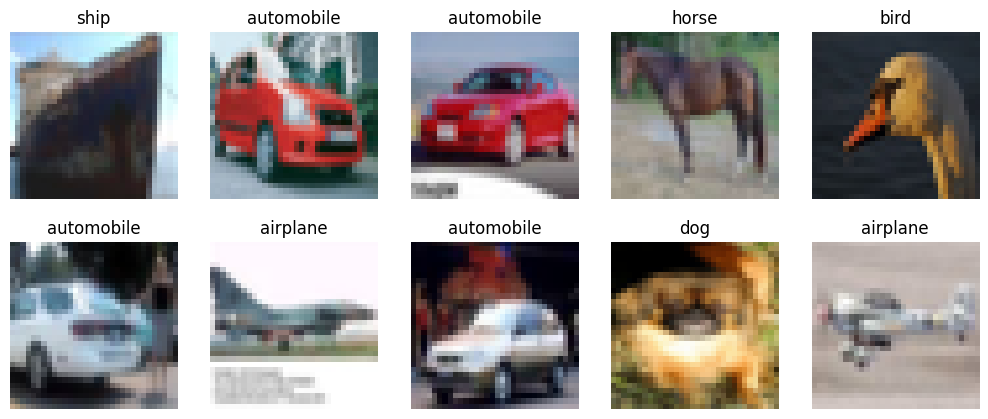

In [16]:
#Берём первый батч и показываем
dataiter = iter(train_dataloader) #создает итератор
images, labels = next(dataiter) #берёт первый батч из итератора. next вызывает следующий батч данных и Складывает их в два тензора: images → [batch_size, 3, 32, 32] labels → [batch_size]
imgshow_grid(images, labels, n=10)

In [5]:
import torch.nn as nn
import torch.nn.functional as F

In [20]:
#создадим один сверточный блок который многократно можно использовать в CNN
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
  # in_channels - количество входных каналов изображения RGB = 3
  # out_channels — выходные карты признаков (количество фильтров которые мы хотим получить) Карта признаков — это результат применения фильтра к входным каналам. Она показывает «наличие определённого признака» в разных частях изображения.
  # kernel_size размер свёрточного ядра 3×3
  # stride=1 — шаг свёртки по пикселям
  # padding=1 — добавление рамки (1 пиксель с каждой стороны), чтобы размер выхода совпадал с входом
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding), #слой свертки для двумерной свертки (изображения) (batch, channels, H, W) получаем карту признаков после фильтра батч
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )


In [19]:
#сверточная неронная сеть
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.block1 = conv_block(3, 32)   # сверточные блоки
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2, 2)    # Это помогает сократить размерность и вычисления, а также сделать модель более устойчивой к смещениям объектов.
        self.fc1 = nn.Linear(128*4*4, 256)  # Полносвязный слой.128 каналов → 128 × 4 × 4 значений. 128×4×4 = 2048 → 256 нейронов
        self.fc2 = nn.Linear(256, 10)       # 10 классов CIFAR-10 выдаёт

    def forward(self, x):
        x = self.pool(self.block1(x))
        x = self.pool(self.block2(x))
        x = self.pool(self.block3(x))
        x = x.view(x.size(0), -1) #x.size(0) — размер батча, -1 автоматически вычисляет оставшуюся размерность (128×4×4 = 2048).
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x # возвращаем логиты


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #обучаем на видеокарте если есть CUDA
model = MyCNN().to(device) #создаем модель
lr = 0.001 #скорость обучения
optimizer = torch.optim.Adam(model.parameters(), lr=lr) #оптимизатор Adam
num_epochs = 20 #эпохи
batch_size = 64 #размер батча


In [ ]:
def get_loss(pred, y_batch): #Функция потерь
    return F.cross_entropy(pred, y_batch)

def get_accuracy(pred, y_batch):
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == y_batch).sum().item() / y_batch.size(0)


In [ ]:
# Списки для сохранения loss по эпохам
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_acc = 0

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad() #обнуляем градиенты с прошлой итерации.
        pred = model(X_batch) #прямой проход (forward) через сеть, получаем логиты для батча.
        loss = get_loss(pred, y_batch) #считаем cross-entropy loss для этого батча.
        loss.backward() #вычисляем градиенты.
        optimizer.step() #обновляем веса модели.

        train_loss += loss.item()
        train_acc += get_accuracy(pred, y_batch)

    # Средний loss и accuracy train за эпоху
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # ----- Оценка на test датасете -----
    model.eval()
    test_loss = 0
    test_acc = 0

    with torch.no_grad():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            pred = model(X_test)
            loss_t = get_loss(pred, y_test)
            acc_t = get_accuracy(pred, y_test)

            test_loss += loss_t.item()
            test_acc += acc_t

    # Средний test loss и accuracy
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    # Сохраняем в списки
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/20, Train Loss: 1.1926, Train Acc: 0.5706, Test Loss: 1.0028, Test Acc: 0.6428
Epoch 2/20, Train Loss: 0.8161, Train Acc: 0.7146, Test Loss: 0.8112, Test Acc: 0.7181
Epoch 3/20, Train Loss: 0.6856, Train Acc: 0.7605, Test Loss: 0.7514, Test Acc: 0.7394
Epoch 4/20, Train Loss: 0.5872, Train Acc: 0.7947, Test Loss: 0.6622, Test Acc: 0.7713
Epoch 5/20, Train Loss: 0.5059, Train Acc: 0.8239, Test Loss: 0.6664, Test Acc: 0.7694
Epoch 6/20, Train Loss: 0.4427, Train Acc: 0.8458, Test Loss: 0.7514, Test Acc: 0.7657
Epoch 7/20, Train Loss: 0.3788, Train Acc: 0.8671, Test Loss: 0.6665, Test Acc: 0.7855
Epoch 8/20, Train Loss: 0.3207, Train Acc: 0.8868, Test Loss: 0.7244, Test Acc: 0.7720
Epoch 9/20, Train Loss: 0.2713, Train Acc: 0.9048, Test Loss: 0.7781, Test Acc: 0.7726
Epoch 10/20, Train Loss: 0.2388, Train Acc: 0.9157, Test Loss: 0.7841, Test Acc: 0.7832
Epoch 11/20, Train Loss: 0.1950, Train Acc: 0.9313, Test Loss: 0.8341, Test Acc: 0.7748
Epoch 12/20, Train Loss: 0.1718, Train Ac

In [ ]:
model.eval() #Переводит модель в режим оценки (evaluation mode):
test_acc = 0 #Инициализация переменной для накопления точности по всем батчам тестового набора.
with torch.no_grad(): #Блок torch.no_grad() отключает автоматическое вычисление градиентов.
    for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        pred = model(X_test) #Пропускаем батч через модель → получаем логиты для каждого класса.
        test_acc += get_accuracy(pred, y_test) #Считаем точность батча и добавляем к общему накопителю.
test_acc /= len(test_dataloader)
print(f"Test accuracy: {test_acc:.4f}") #Делим накопленную точность на количество батчей, чтобы получить среднюю точность по всему тестовому набору.


Test accuracy: 0.7857


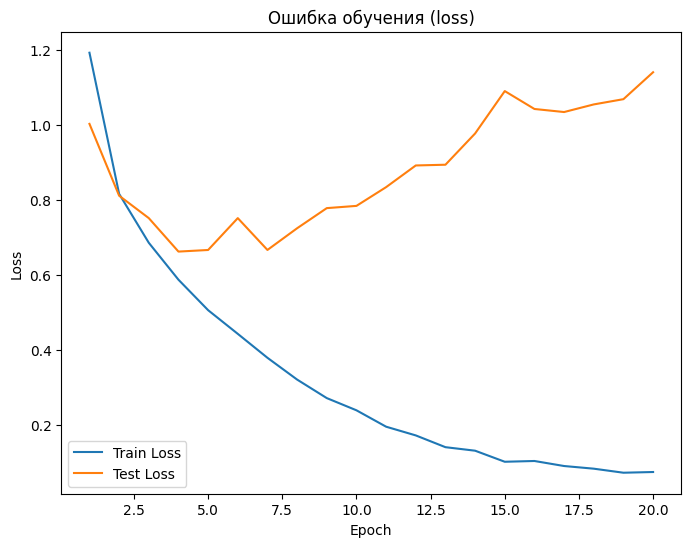


Ошибка классификации на тестовом наборе (Test loss): 0.8813
Точность на тестовом наборе (Test accuracy): 0.7651


In [ ]:
# График ошибки обучения
plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), test_losses, label="Test Loss")
plt.title("Ошибка обучения (loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Вывод финальных test метрик
print(f"\nОшибка классификации на тестовом наборе (Test loss): {np.mean(test_losses):.4f}")
print(f"Точность на тестовом наборе (Test accuracy): {np.mean(test_accuracies):.4f}")


100%|██████████| 170M/170M [00:02<00:00, 75.7MB/s]


Epoch 1/20 | Train Loss: 1.4221  Acc: 0.4821 | Test Loss: 1.1005  Acc: 0.5960
Epoch 2/20 | Train Loss: 1.0741  Acc: 0.6174 | Test Loss: 0.8975  Acc: 0.6819
Epoch 3/20 | Train Loss: 0.9455  Acc: 0.6655 | Test Loss: 0.8453  Acc: 0.7037
Epoch 4/20 | Train Loss: 0.8648  Acc: 0.6938 | Test Loss: 0.7867  Acc: 0.7185
Epoch 5/20 | Train Loss: 0.8088  Acc: 0.7145 | Test Loss: 0.7362  Acc: 0.7414
Epoch 6/20 | Train Loss: 0.7656  Acc: 0.7300 | Test Loss: 0.7264  Acc: 0.7459
Epoch 7/20 | Train Loss: 0.7348  Acc: 0.7419 | Test Loss: 0.6965  Acc: 0.7546
Epoch 8/20 | Train Loss: 0.7016  Acc: 0.7536 | Test Loss: 0.6911  Acc: 0.7566
Epoch 9/20 | Train Loss: 0.6728  Acc: 0.7647 | Test Loss: 0.6683  Acc: 0.7639
Epoch 10/20 | Train Loss: 0.6468  Acc: 0.7721 | Test Loss: 0.6708  Acc: 0.7671
Epoch 11/20 | Train Loss: 0.6271  Acc: 0.7786 | Test Loss: 0.6526  Acc: 0.7706
Epoch 12/20 | Train Loss: 0.6028  Acc: 0.7858 | Test Loss: 0.6342  Acc: 0.7800
Epoch 13/20 | Train Loss: 0.5912  Acc: 0.7923 | Test Loss: 0.

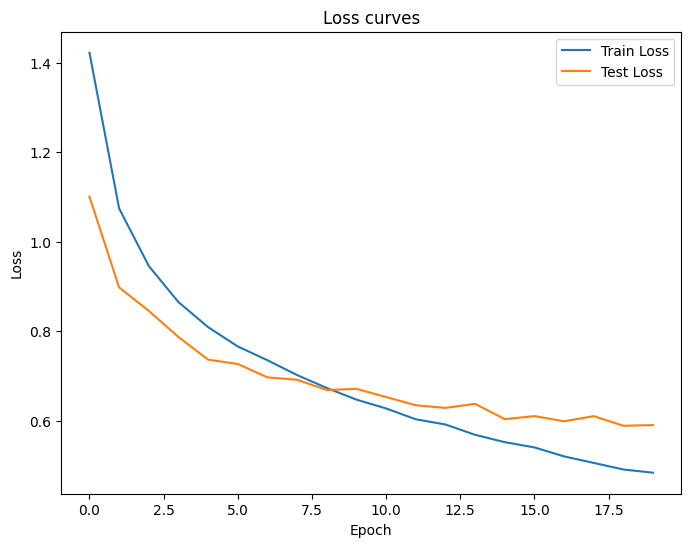

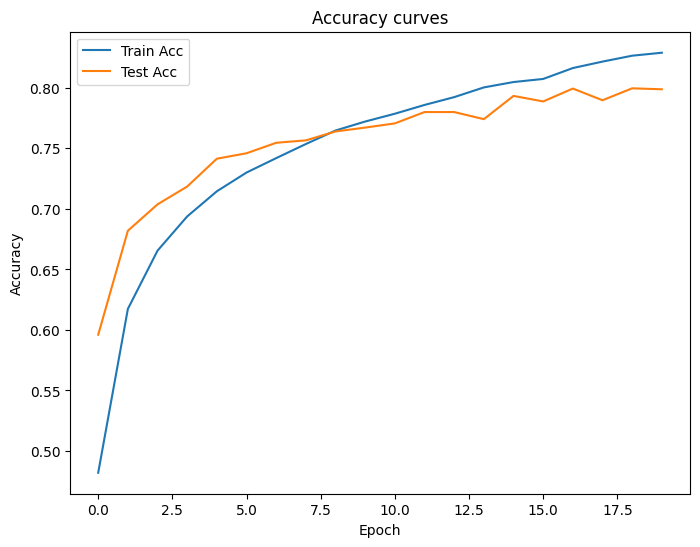

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./', train=True, download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./', train=False, download=True, transform=transform_test)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes


def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.block1 = conv_block(3, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.4)  #случайно зануляет 40% нейронов. регуляризация, которая помогает бороться с overfitting (переобучением).

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.block1(x))   # 32 -> 16
        x = self.pool(self.block2(x))   # 16 -> 8
        x = self.pool(self.block3(x))   # 8 -> 4

        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
num_epochs = 20

def get_loss(pred, y):
    return F.cross_entropy(pred, y)

def get_accuracy(pred, y):
    return (pred.argmax(dim=1) == y).float().mean().item()

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

best_loss = float('inf')
patience = 5
trigger = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_acc = 0, 0

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = get_loss(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += get_accuracy(pred, y_batch)

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    model.eval()
    test_loss, test_acc = 0, 0

    with torch.no_grad():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            pred = model(X_test)

            l = get_loss(pred, y_test)
            a = get_accuracy(pred, y_test)

            test_loss += l.item()
            test_acc += a

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

    # Early stopping Останавливает обучение, если тестовый loss не улучшается 5 эпох подряд.
    if test_loss < best_loss:
        best_loss = test_loss
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("Early stopping triggered!")
            break

print(f"\nFinal Test accuracy: {test_acc:.4f}")


plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()


Epoch 1/20 | Train Loss: 1.5850  Acc: 0.4168 | Test Loss: 1.2601  Acc: 0.5433
Epoch 2/20 | Train Loss: 1.2800  Acc: 0.5383 | Test Loss: 1.0373  Acc: 0.6335
Epoch 3/20 | Train Loss: 1.1579  Acc: 0.5877 | Test Loss: 0.9569  Acc: 0.6660
Epoch 4/20 | Train Loss: 1.0850  Acc: 0.6118 | Test Loss: 0.9248  Acc: 0.6675
Epoch 5/20 | Train Loss: 1.0284  Acc: 0.6337 | Test Loss: 0.8413  Acc: 0.7048
Epoch 6/20 | Train Loss: 0.9911  Acc: 0.6491 | Test Loss: 0.8011  Acc: 0.7153
Epoch 7/20 | Train Loss: 0.9556  Acc: 0.6622 | Test Loss: 0.7861  Acc: 0.7184
Epoch 8/20 | Train Loss: 0.9186  Acc: 0.6744 | Test Loss: 0.7545  Acc: 0.7357
Epoch 9/20 | Train Loss: 0.8975  Acc: 0.6833 | Test Loss: 0.7418  Acc: 0.7330
Epoch 10/20 | Train Loss: 0.8789  Acc: 0.6908 | Test Loss: 0.7071  Acc: 0.7530
Epoch 11/20 | Train Loss: 0.8556  Acc: 0.6988 | Test Loss: 0.6890  Acc: 0.7538
Epoch 12/20 | Train Loss: 0.8420  Acc: 0.7053 | Test Loss: 0.7010  Acc: 0.7518
Epoch 13/20 | Train Loss: 0.8246  Acc: 0.7111 | Test Loss: 0.

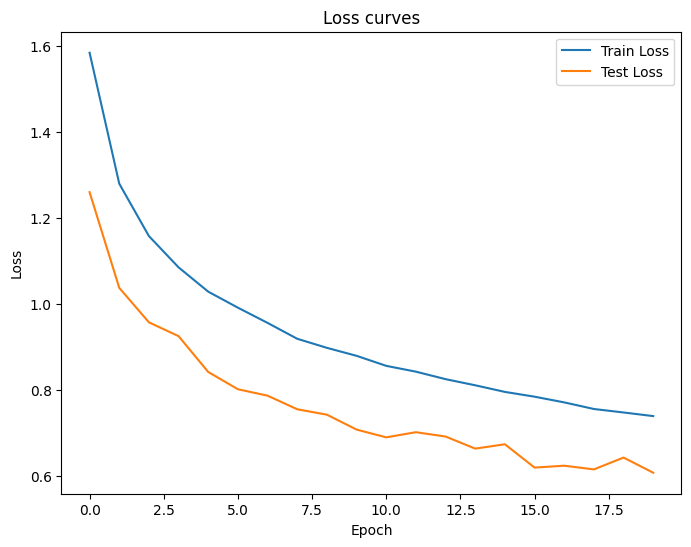

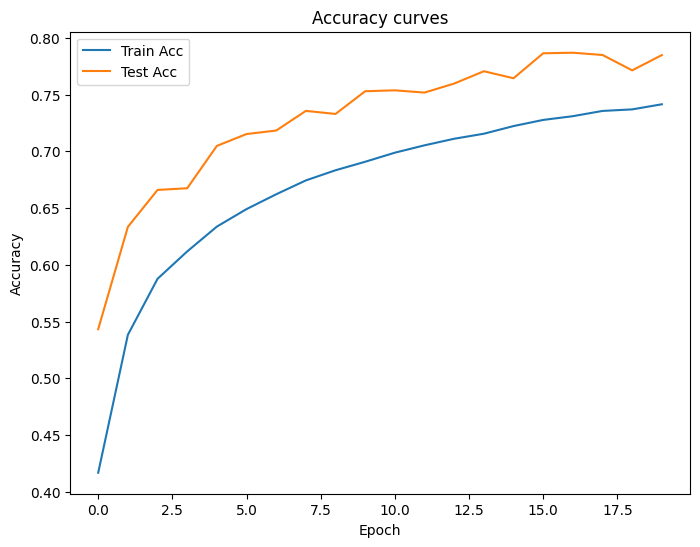

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Аугментации только для train
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),              # зеркальное отражение
    transforms.RandomCrop(32, padding=4),           # случайное обрезание
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# На тесте никакого random!
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./', train=True, download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./', train=False, download=True, transform=transform_test)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes


def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.block1 = conv_block(3, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.block1(x))   # 32 -> 16
        x = self.pool(self.block2(x))   # 16 -> 8
        x = self.pool(self.block3(x))   # 8 -> 4

        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
num_epochs = 20

def get_loss(pred, y):
    return F.cross_entropy(pred, y)

def get_accuracy(pred, y):
    return (pred.argmax(dim=1) == y).float().mean().item()

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

best_loss = float('inf')
patience = 5
trigger = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_acc = 0, 0

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = get_loss(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += get_accuracy(pred, y_batch)

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    model.eval()
    test_loss, test_acc = 0, 0

    with torch.no_grad():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            pred = model(X_test)

            l = get_loss(pred, y_test)
            a = get_accuracy(pred, y_test)

            test_loss += l.item()
            test_acc += a

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

    # Early stopping Останавливает обучение, если тестовый loss не улучшается 5 эпох подряд.
    if test_loss < best_loss:
        best_loss = test_loss
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("Early stopping triggered!")
            break

print(f"\nFinal Test accuracy: {test_acc:.4f}")


plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()
